In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

In [2]:
# ------------------------------------------------------------------
# CONFIGURACIÓN: editá estas variables según lo que necesites
# ------------------------------------------------------------------
ARCHIVO = "Analisis_Exploratorio_de_Datos_VJ.xlsx"                  # nombre (o ruta) del archivo Excel
COLUMNAS = ["jugadores (descargas)", "precio inicial"]         # 2 o más columnas a analizar
# ------------------------------------------------------------------


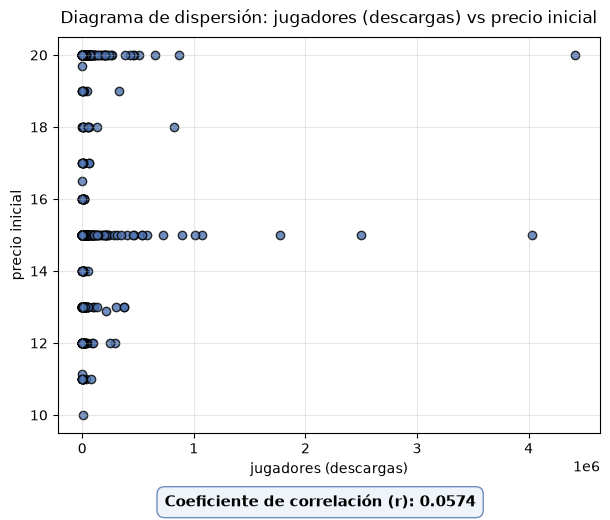

Coeficiente de correlación (r): 0.0574


In [3]:

def cargar_datos(archivo: str, columnas: list) -> pd.DataFrame:
    ruta = archivo if os.path.isabs(archivo) else os.path.join(os.getcwd(), archivo)

    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_excel(ruta)

    faltantes = [c for c in columnas if c not in df.columns]
    if faltantes:
        raise ValueError(
            f"Las siguientes columnas no existen: {faltantes}. "
            f"Columnas disponibles: {list(df.columns)}"
        )

    datos = df[columnas].apply(pd.to_numeric, errors="coerce").dropna()

    if datos.empty:
        raise ValueError("No hay datos numéricos válidos en las columnas seleccionadas.")

    return datos


def graficar_dispersion_simple(datos: pd.DataFrame, col_x: str, col_y: str):
    r = datos[col_x].corr(datos[col_y])

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.scatter(datos[col_x], datos[col_y], color="#4C72B0", edgecolor="black", alpha=0.8)
    ax.set_title(f"Diagrama de dispersión: {col_x} vs {col_y}", fontsize=12, pad=10)
    ax.set_xlabel(col_x, fontsize=10)
    ax.set_ylabel(col_y, fontsize=10)
    ax.grid(alpha=0.3)

    # Coeficiente de correlación en la parte inferior del gráfico
    fig.text(
        0.5,
        0.02,
        f"Coeficiente de correlación (r): {r:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#EBF2FA", edgecolor="#4C72B0", alpha=0.8)
    )

    plt.subplots_adjust(bottom=0.16)
    plt.show()

    print(f"Coeficiente de correlación (r): {r:.4f}")


def graficar_matriz_dispersion(datos: pd.DataFrame):
    ejes = scatter_matrix(
        datos,
        figsize=(2.6 * len(datos.columns), 2.6 * len(datos.columns)),
        diagonal="hist",
        color="#4C72B0",
        alpha=0.8,
    )
    plt.suptitle("Matriz de diagramas de dispersión", y=1.02)
    plt.tight_layout()
    plt.show()

    print("\nMatriz de coeficientes de correlación:")
    print(datos.corr().round(4))


def main():
    if len(COLUMNAS) < 2:
        raise ValueError("Necesitás indicar al menos 2 columnas en COLUMNAS.")

    datos = cargar_datos(ARCHIVO, COLUMNAS)

    if len(COLUMNAS) == 2:
        graficar_dispersion_simple(datos, COLUMNAS[0], COLUMNAS[1])
    else:
        graficar_matriz_dispersion(datos)


if __name__ == "__main__":
    main()